In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import timeit
from scipy.sparse import csr_array,block_array
import os

pseudospectral on the gpu

In [2]:
b=2.0 
c=0.8
couplings=['1.0,0,0,1', '1.0,0,6,1', '1.0,0,12,1', '-%f,0,7,1'%(b), \
           '-%f,0,13,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,7,1', '1.0,1,13,1', '%f,1,6,1'%(b),'%f,1,12,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('2dcgle1coupling.dat','w')
for line in couplings:
    print(line,file=file)
file.close()

In [3]:
Ns=[512,512]
N=Ns[0]*Ns[1]
Ls=[200.0,200.0]
T=100

os.system('module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i -L %f,%f -n 2 -v -D1 -a 1E-6 -r 1E-6 2dcgle1'%(T,Ns[0],Ns[1],Ls[0],Ls[1]))

Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	5.298e+01	-2.936e-03	0.011305	8452	
runtime: 52.991134


0

runtime: 52.991134



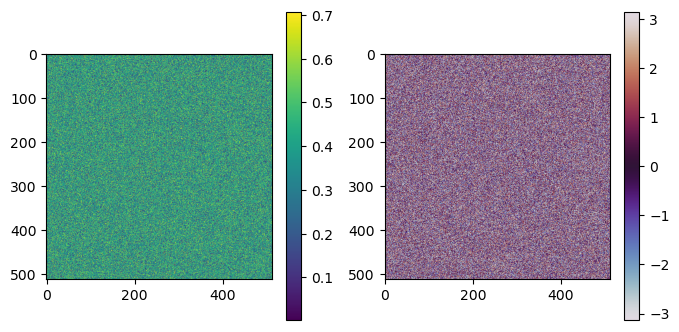

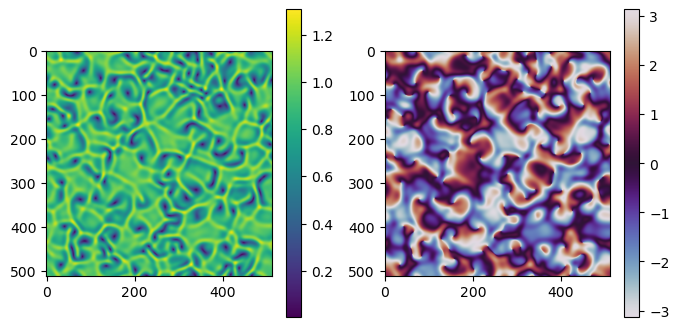

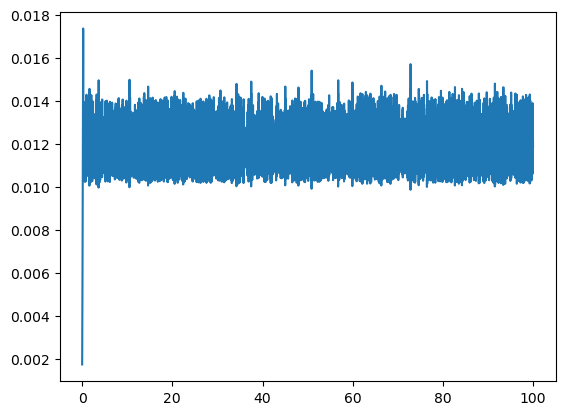

In [4]:
filebase='2dcgle1'
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')
U0=ys[0].reshape(-1)

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()
    
plt.plot(ts[:-1],np.diff(ts))

pseudospectral on the cpu (note: this takes advantage of complex fft, which is faster than two real ffts used in cuda) and we specialize to only calculate laplacian instead of each spatial derivative

runtime:  783.8370681019733


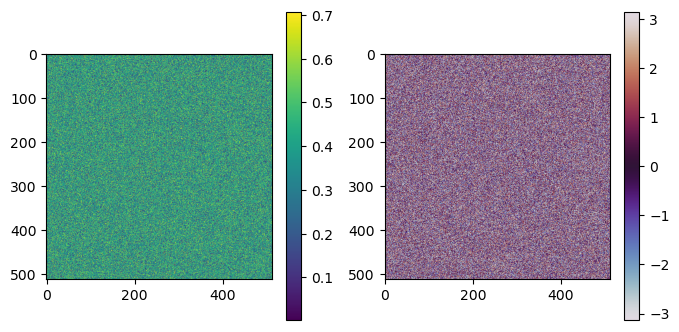

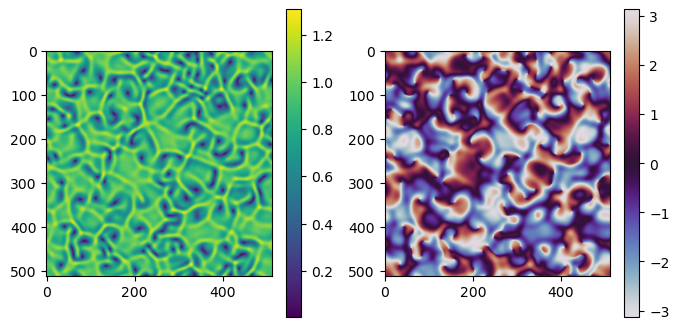

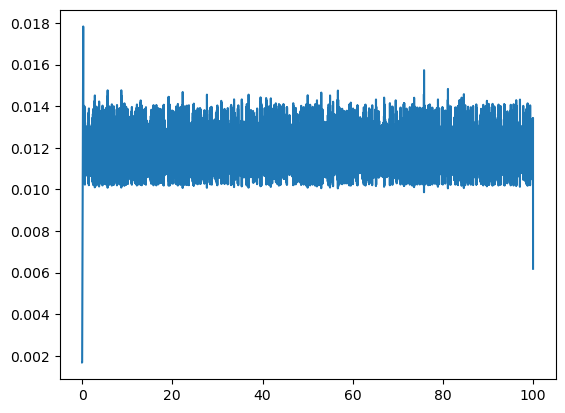

In [5]:
def lap(y,Ls,Ns):
    yfft=np.fft.fftn(y)
    ret=-np.fft.fftfreq(Ns[0],Ls[0]/(2*np.pi*Ns[0])).reshape((Ns[0],1))**2*yfft
    ret=ret-np.fft.fftfreq(Ns[1],Ls[1]/(2*np.pi*Ns[1])).reshape((1,Ns[1]))**2*yfft
    return np.fft.ifftn(ret)

def cgle(t, U, b, c, Ls, Ns):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

start=timeit.default_timer()
sol1=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns],method='RK45',rtol=1E-6,atol=1E-6)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()

plt.plot(ts[:-1],np.diff(ts))

finite difference on cpu

runtime:  255.65813058195636


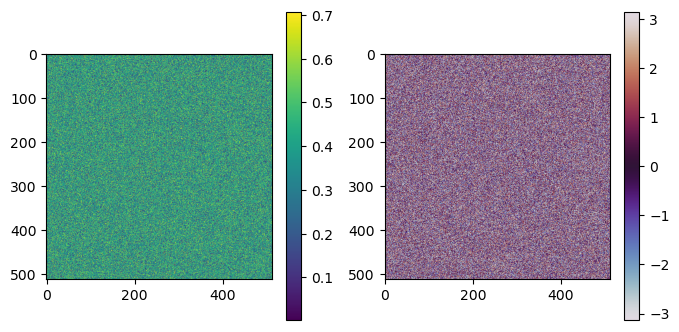

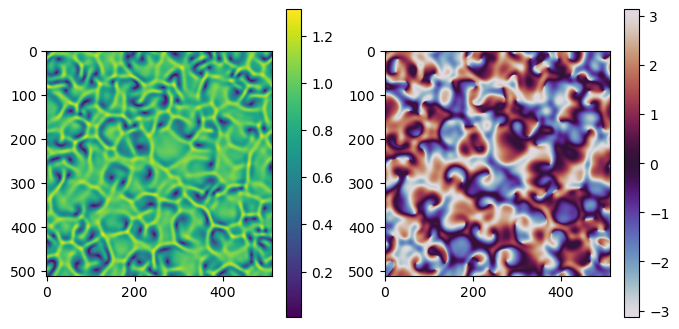

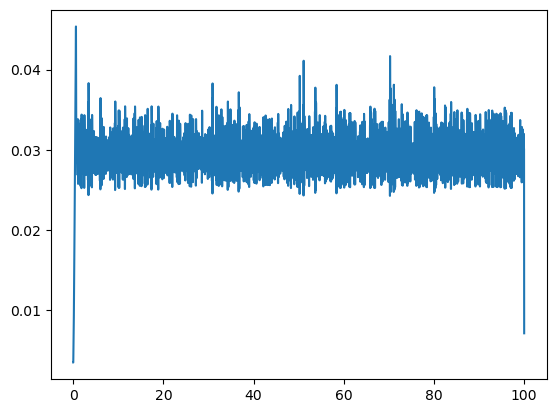

In [6]:
def lap(y,Ls,Ns):
    return (np.roll(y,1,axis=0)+np.roll(y,-1,axis=0)-2*y)/(Ls[0]/Ns[0])**2+(np.roll(y,1,axis=1)+np.roll(y,-1,axis=1)-2*y)/(Ls[1]/Ns[1])**2

def cgle(t, U, b, c, Ls, Ns):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

start=timeit.default_timer()
sol1=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns],method='RK45',rtol=1E-6,atol=1E-6)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()

plt.plot(ts[:-1],np.diff(ts))

Finite difference implicit method with sparse jacobian. The stepsize decreaseses much more slowly with N, but the work required per step grows quickly. Could an iterative solver on the gpu be more efficient?

runtime:  410.8402231410146


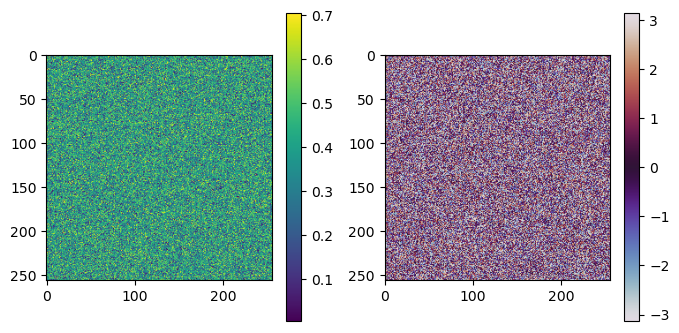

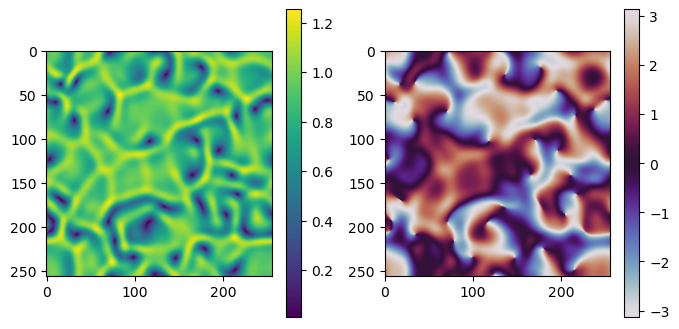

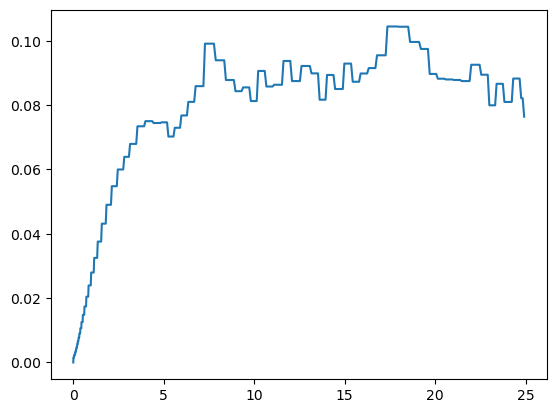

In [34]:
def lap(y,Ls,Ns):
    return (np.roll(y,1,axis=0)+np.roll(y,-1,axis=0)-2*y)/(Ls[0]/Ns[0])**2+(np.roll(y,1,axis=1)+np.roll(y,-1,axis=1)-2*y)/(Ls[1]/Ns[1])**2

def cgle(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

def jac(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N]
    Y=U[N:]
#     retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retXX=I+JI-(2*X*I)*(X+c*Y)-(X**2+Y**2)*I
    retXY=-b*JI-(2*Y*I)*(X+c*Y)-(X**2+Y**2)*I*c
#     retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    retYX=b*JI-(2*X*I)*(Y-c*X)+(X**2+Y**2)*I*c
    retYY=I+JI-(2*Y*I)*(Y-c*X)-(X**2+Y**2)*I
    return block_array([[retXX,retYX],[retXY, retYY]]).T


I=csr_array(np.eye(N))
Ip0=csr_array(np.roll(np.eye(N).reshape(Ns+Ns),1,axis=0).reshape([N,N]))
Im0=csr_array(np.roll(np.eye(N).reshape(Ns+Ns),-1,axis=0).reshape([N,N]))
Ip1=csr_array(np.roll(np.eye(N).reshape(Ns+Ns),1,axis=1).reshape([N,N]))
Im1=csr_array(np.roll(np.eye(N).reshape(Ns+Ns),-1,axis=1).reshape([N,N]))
JI=(Ip0+Im0-2*I)/(Ls[0]/Ns[0])**2+(Ip1+Im1-2*I)/(Ls[1]/Ns[1])**2

start=timeit.default_timer()
sol1=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns,I,JI],method='BDF',jac=jac,rtol=1E-6,atol=1E-6)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()

plt.plot(ts[:-1],np.diff(ts))

runtime:  1125.3048262000084


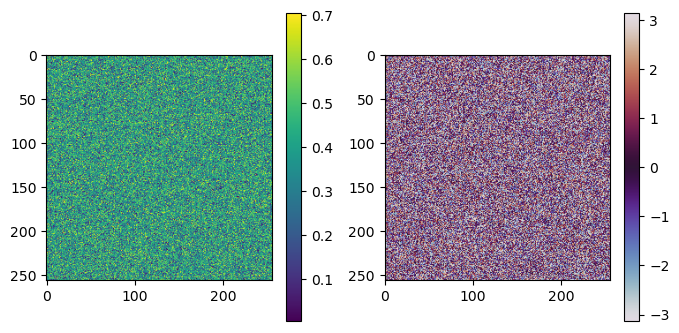

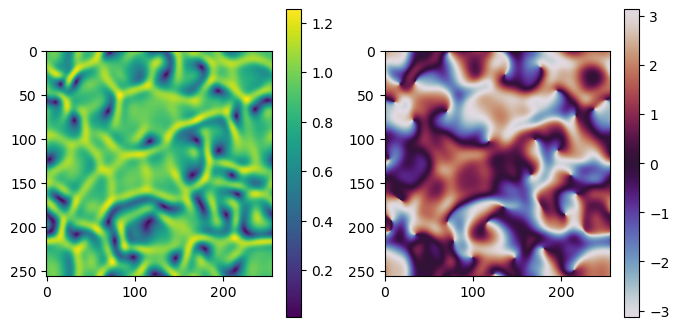

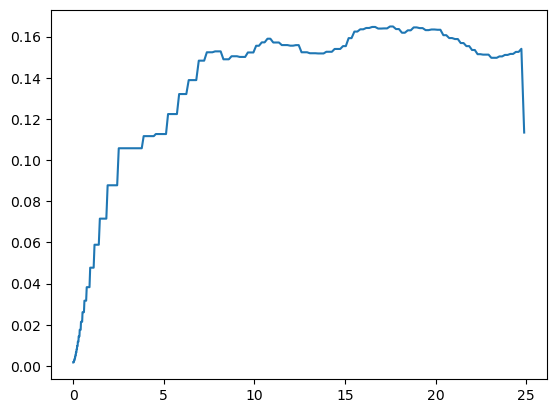

In [35]:
def lap(y,Ls,Ns):
    return (np.roll(y,1,axis=0)+np.roll(y,-1,axis=0)-2*y)/(Ls[0]/Ns[0])**2+(np.roll(y,1,axis=1)+np.roll(y,-1,axis=1)-2*y)/(Ls[1]/Ns[1])**2

def cgle(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

def jac(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N]
    Y=U[N:]
#     retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retXX=I+JI-(2*X*I)*(X+c*Y)-(X**2+Y**2)*I
    retXY=-b*JI-(2*Y*I)*(X+c*Y)-(X**2+Y**2)*I*c
#     retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    retYX=b*JI-(2*X*I)*(Y-c*X)+(X**2+Y**2)*I*c
    retYY=I+JI-(2*Y*I)*(Y-c*X)-(X**2+Y**2)*I
    return block_array([[retXX,retYX],[retXY, retYY]]).T


I=csr_array(np.eye(N))
Ip0=csr_array(np.roll(np.eye(N).reshape(Ns+Ns),1,axis=0).reshape([N,N]))
Im0=csr_array(np.roll(np.eye(N).reshape(Ns+Ns),-1,axis=0).reshape([N,N]))
Ip1=csr_array(np.roll(np.eye(N).reshape(Ns+Ns),1,axis=1).reshape([N,N]))
Im1=csr_array(np.roll(np.eye(N).reshape(Ns+Ns),-1,axis=1).reshape([N,N]))
JI=(Ip0+Im0-2*I)/(Ls[0]/Ns[0])**2+(Ip1+Im1-2*I)/(Ls[1]/Ns[1])**2

start=timeit.default_timer()
sol1=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns,I,JI],method='Radau',jac=jac,rtol=1E-6,atol=1E-6)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()

plt.plot(ts[:-1],np.diff(ts))

In [38]:
len(sol1.t)

270